# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Nguyễn Huỳnh Gia Bảo"  # TODO: Họ và tên
STUDENT_ID = "2550015"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Huỳnh Gia Bảo (2550015)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\LENOVO\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
row_max = np.max(logits, axis=1, keepdims=True)
# shifted_logits = ...
shifted_logits = logits - row_max
# exp_logits = ...
exp_logits = np.exp(shifted_logits)
# class_probabilities = ...
class_probabilities = exp_logits / np.sum(exp_logits, axis=1,keepdims=True)
# predicted_classes = ...
predicted_classes = np.argmax(class_probabilities, axis=1)
# confidence_scores = ...
confidence_scores = np.max(class_probabilities, axis=1)

In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
# train_feature_mean = ...
train_feature_mean = np.mean(X_train,axis=0)
# train_feature_std = ...
train_feature_std = np.std(X_train,axis=0)
# X_train_scaled = ...
X_train_scaled = (X_train-train_feature_mean)/train_feature_std
# X_val_scaled = ...
X_val_scaled = (X_val-train_feature_mean)/train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
# correct_mask = ...
correct_mask = predicted_classes == true_labels
# high_confidence_mask = ...
high_confidence_mask = confidence_scores >= confidence_threshold
# review_mask = ...
review_mask = (~correct_mask) | (~high_confidence_mask)
# review_indices = ...
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
# normalized_batch = ...
normalized_batch = image_batch_uint8.astype(np.float32)/255.0
# augmented_batch = ...
augmented_batch = normalized_batch[:, :, ::-1, :].copy()
# augmented_batch[0, 0, 0, 0] = ...
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
# raw_df = ...
raw_df = pd.read_csv(DATA_PATH, na_values=[])
# raw_shape = ...
raw_shape = raw_df.shape
# raw_missing_marker_count = ...
raw_missing_marker_count = (raw_df == "?").sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
# df_clean = ...
df_clean = raw_df.replace("?", np.nan)
# for column in NUMERIC_COLUMNS:
#     ...
# missing_by_column = ...
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isna().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
Ta không nên fill tất cả col bằng cùng giá trị vì mỗi col có ý nghĩa và phân phối dữ liệu khác nhau. Nếu ta thay cùng giá trị sẽ làm sai lệch dữ liệu.

Với price, ta nên dùng drop sẽ phù hợp hơn cho bài này. Vì ta thấy chỉ có 4 mẫu bị thiếu trên tổng 205 mẫu nên không đáng kể, nếu ta fill sẽ làm sai lệch và giảm tính chính xác. Do đó ta nên để trống cũng giúp dữ liệu thực tế hơn.

Ta thấy normalize_losses thiếu khá nhiều dữ liệu dẫn đến các phép tính mean, median, std sẽ kém chính xác. Nếu ta bỏ đi những dòng thiếu thì số lượng dữ liệu giảm đi quá nhiều, còn ta thêm median hoặc mean vào cũng có thể gây lệch đáng kể.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
# analysis_df = ...
analysis_df = df_clean[AUTO_FEATURES].dropna()
# X_auto = ...
X_auto = analysis_df.to_numpy(dtype=np.float64)
# auto_feature_mean = ...
auto_feature_mean = np.mean(X_auto, axis=0)
# auto_feature_std = ...
auto_feature_std = np.std(X_auto, axis=0)
# X_auto_scaled = ...
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
# price_index = ...
price_index = AUTO_FEATURES.index("price")
# price_z = ...
price_z = (X_auto[:, price_index] - auto_feature_mean[price_index]) / auto_feature_std[price_index]
# price_outlier_mask = ...
price_outlier_mask = np.abs(price_z) > 2
# price_outliers = ...
price_outliers = analysis_df[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5
# engine_price_corr = ...
engine_size = X_auto[:, AUTO_FEATURES.index("engine_size")]
price = X_auto[:, AUTO_FEATURES.index("price")]
engine_price_corr = np.corrcoef(engine_size, price)[0, 1]
# price_by_body_style = ...
price_by_body_style = (df_clean.groupby("body_style")["price"].mean().sort_index())

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

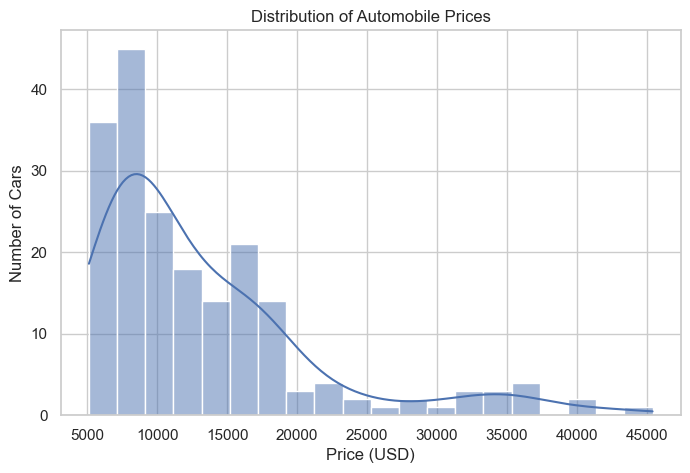

In [20]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(8, 5))
sns.histplot(
    data=analysis_df,
    x="price",
    bins=20,
    kde=True
)
plt.title("Distribution of Automobile Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Cars")

plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Ta thấy giá xe phân bố tập trung ở giá thấp đến trung bình dẫn đến phân phối đồ thị bị lệch phải. Điều này khá hợp lý khi xe giá cao thường là xe sang và số lượng rất ít do giá tiền quá cao. 

## M2.2 Dataset có cân bằng theo body style không?

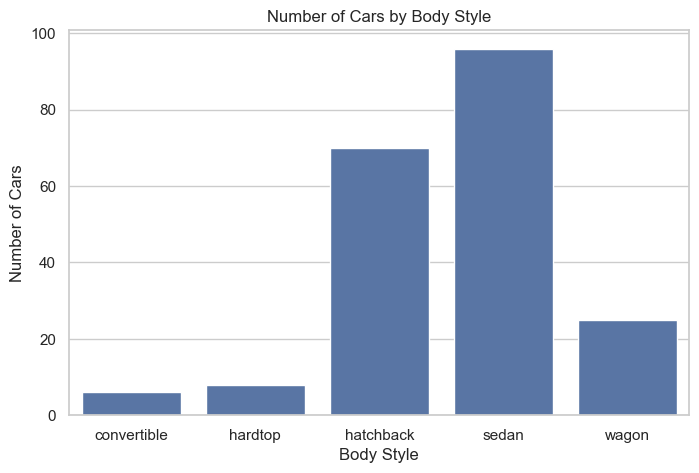

In [21]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_clean,
    x="body_style",
    order=sorted(df_clean["body_style"].unique())
)
plt.title("Number of Cars by Body Style")
plt.xlabel("Body Style")
plt.ylabel("Number of Cars")
plt.show()


**Nhận xét:** <!-- 1--2 câu -->
Ta thấy số lượng giữa các mẫu xe cũng không đồng đều, chủ yếu tập trung vào dòng sedan và hatchback là chính. 

## M2.3 Price khác nhau theo body style ra sao?

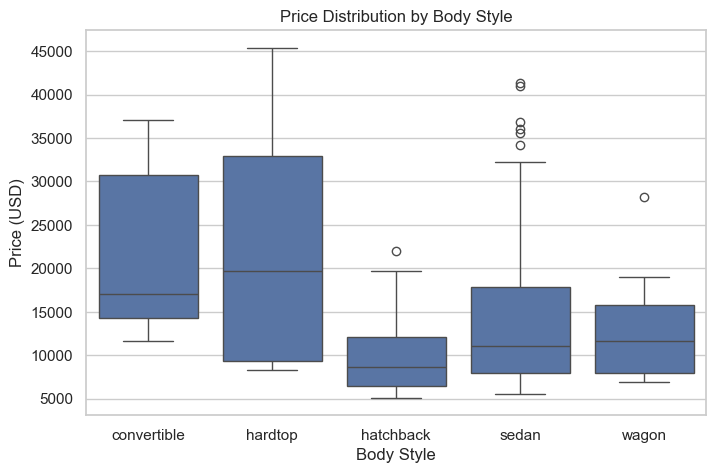

In [22]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean,
    x="body_style",
    y="price",
    order=sorted(df_clean["body_style"].unique())
)
plt.title("Price Distribution by Body Style")
plt.xlabel("Body Style")
plt.ylabel("Price (USD)")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Ta dùng boxplot để thấy rõ được sự khác biệt của price theo bodystyle. Ta nhận thấy giá xe phân bố không đều giữa các bodytype, chủ yếu tập trung vào hardtop và convertible. Vậy ta rút ra được dù số lượng tập trung chủ yếu ở sedan và hatchback nhưng giá lại tập trung ở hardtop và convertible, chứng tỏ đây là 2 dòng xe sang còn 2 dòng kia là xe phổ thông được nhiều ngưởi sử dụng.

## M2.4 Engine size liên quan thế nào tới price?

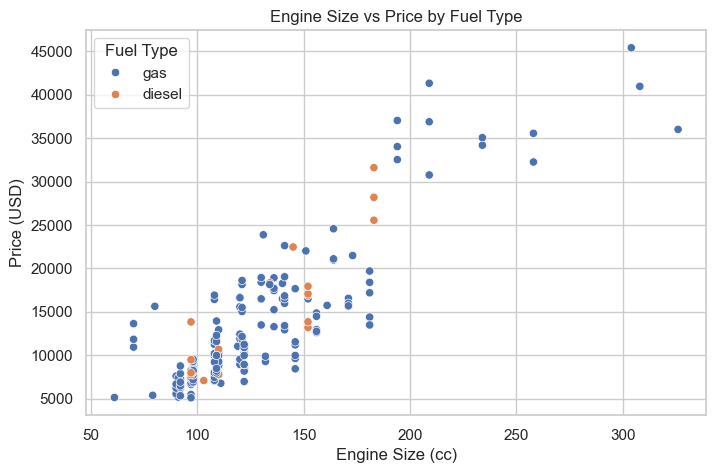

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean,
    x="engine_size",
    y="price",
    hue="fuel_type"
)
plt.title("Engine Size vs Price by Fuel Type")
plt.xlabel("Engine Size (cc)")
plt.ylabel("Price (USD)")
plt.legend(title="Fuel Type")
plt.show()


**Nhận xét:** <!-- 1--2 câu -->
Ta thấy xe có engine size lớn thì giá sẽ cao hơn và đây chính là tương quan giữa engine size và price khi cái này tăng thì cái kia tăng.

## M2.5 Các feature numeric tương quan ra sao?

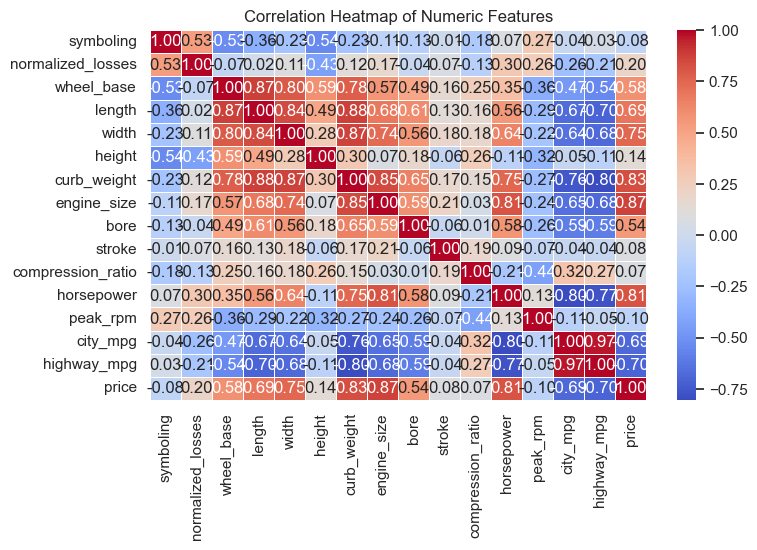

In [24]:
# TODO M2.5: correlation heatmap
plt.Figure(figsize=(10,5))
numeric_df = df_clean.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Ta thấy một số cặp tương quan rất mạnh như là engine size, horsepower và price. City_mpg và highway_mpg thường có tương quan dương mạnh với nhau, trong khi chúng có xu hướng tương quan âm với engine_size và curb_weight.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

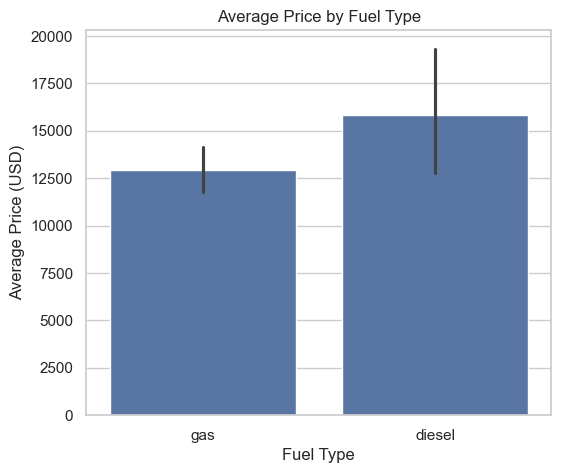

In [25]:
# TODO M2.6: biểu đồ tự chọn
plt.figure(figsize=(6, 5))
sns.barplot(
    data=df_clean,
    x="fuel_type",
    y="price",
    estimator=np.mean
)
plt.title("Average Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price (USD)")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Đây là biểu đồ barplot với câu hỏi "Giá trung bình của xe như thế nào với các loại fuel khác nhau?". Từ đồ thị ta thấy giá trung bình của xe dùng diesel cao hơn xe dùng gas. Do đó fuel type cũng là một ảnh hưởng đối với giá của xe.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->
1) 3-5 phát hiện:
- Giá của xe có phân phối lệch phải, ta thấy được rõ ràng phần lớn các xe có giá từ thấp đến trung bình trong khi có rất ít xe có giá cao. Điều này hoàn toàn khớp với thực tế khi có nhiều người sử dụng xe phổ thông hơn là người sử dụng xe sang.
- Engine size có tương quan dương rất mạnh đối với price. Khi công suất của xe càng lớn thì giá trị cũng sẽ càng cao, ta thấy điều này được thể hiện trên đồ thị.
- Horsepower, engine_size và curb_weight có tương quan dương với price. Correlation heatmap cho thấy các đặc trưng này tăng cùng với giá xe, trong khi city_mpg và highway_mpg có xu hướng tương quan âm với price.

2) Hạn chế của dataset:
- Dataset có nhiều giá trị bị thiếu đi đặc biệt là ở phần normolized_losses, những phần như price, horsepower,... cũng thiếu nhưng không đáng kể bằng.
- Số lượng mẫu của data chưa đủ nhiều để thật sự tính toán và thống kê, ngoài ra số lượng xe giữa 2 loại fuel không đều nên không thể kết luận chắc chắn được.

3) Correlation không đồng nghĩa causation: 
engine_size và price có tương quan dương mạnh, nhưng điều đó không có nghĩa là tăng kích thước động cơ sẽ trực tiếp làm giá xe tăng.Một chiếc xe có giá cao còn chịu ảnh hưởng của nhiều yếu tố khác như: thương hiệu, công nghệ, chất lượng vật liệu, phân khúc xe. Do đó, tương quan chỉ cho thấy hai biến có xu hướng thay đổi cùng nhau, không chứng minh được quan hệ nhân quả.

4) Một câu hỏi:
Yếu tố nào ảnh hưởng mạnh nhất đến giá xe nếu xét đồng thời nhiều đặc trưng như engine_size, horsepower, curb_weight, fuel_type và body_style? Ta có thể trả lời bằng xây dựng mô hình Linear Regression để đánh giá.